# Predicting the Sale Price of Bulldozers using Machine Learning
> The goal of the project is to predict the sale price of a particular piece of heavy equiment at auction based on it's usage, equipment type, and configuaration.  The data is sourced from auction result postings and includes information on usage and equipment configurations.

## Data
The data is downloaded from the Kaggle Bluebook for Bulldozers competition: https://www.kaggle.com/c/bluebook-for-bulldozers/data

The data for this competition is split into three parts:
* **Train.csv** is the training set, which contains data through the end of 2011.
* **Valid.csv** is the validation set, which contains data from January 1, 2012 - April 30, 2012 You make predictions on this set throughout the majority of the competition. Your score on this set is used to create the public leaderboard.
* **Test.csv** is the test set, which won't be released until the last week of the competition. It contains data from May 1, 2012 - November 2012. Your score on the test set determines your final rank for the competition.

The key fields are in train.csv are:
* **SalesID:** the uniue identifier of the sale
* **MachineID:** the unique identifier of a machine.  A machine can be sold multiple times
* **saleprice:** what the machine sold for at auction (only provided in train.csv)
* **saledate:** the date of the sale

## Evaluation
The evaluation metric for this project is the RMSLE (root mean squared log error) between the actual and predicted auction prices.

## Features
> Can be found in the Data Dictionary.xlsx in the data folder



In [1]:
# Importing the relevant libraries for the prokect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
# Import the training and validation sets
df = pd.read_csv("data/bluebook-for-bulldozers/TrainAndValid.csv", low_memory=False)
df

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412693,6333344,10000.0,1919201,21435,149,2.0,2005,NaN,NaN,3/7/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412694,6333345,10500.0,1882122,21436,149,2.0,2005,NaN,NaN,1/28/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412695,6333347,12500.0,1944213,21435,149,2.0,2005,NaN,NaN,1/28/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412696,6333348,10000.0,1794518,21435,149,2.0,2006,NaN,NaN,3/7/2012 0:00,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   object 
 9   saledate                  412698 non-null  object 
 10  fiModelDesc               412698 non-null  object 
 11  fiBaseModel               412698 non-null  object 
 12  fiSecondaryDesc           271971 non-null  object 
 13  fiModelSeries             58667 non-null   o

In [5]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

In [6]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

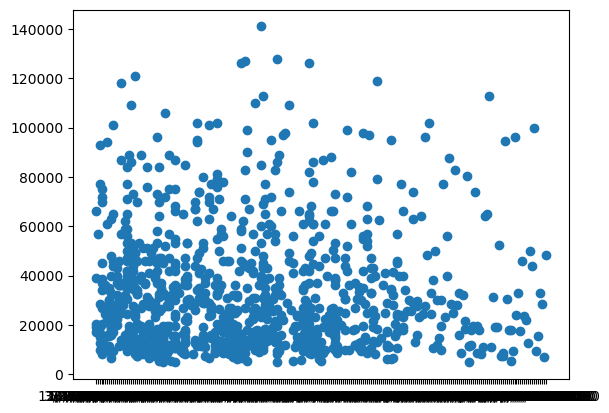

In [7]:
plt.scatter(df.saledate[:1000], df.SalePrice[:1000]);

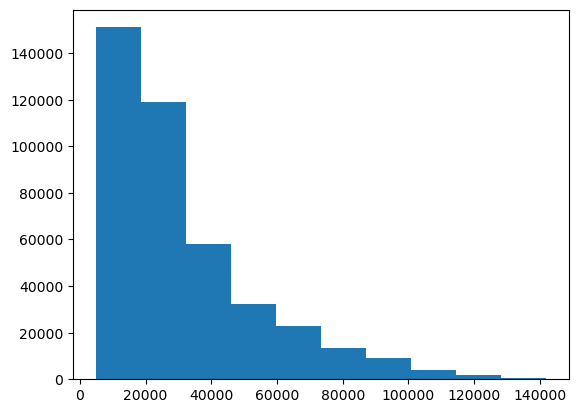

In [10]:
plt.hist(df.SalePrice);

### Parsing dates
Since this is a time series data, we need to enrich the time & date as rich as possible

In [12]:
# Import data again but with parse dates
df = pd.read_csv("data/bluebook-for-bulldozers/TrainAndValid.csv", low_memory=False, parse_dates=["saledate"])
df

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412693,6333344,10000.0,1919201,21435,149,2.0,2005,NaN,NaN,2012-03-07,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412694,6333345,10500.0,1882122,21436,149,2.0,2005,NaN,NaN,2012-01-28,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412695,6333347,12500.0,1944213,21435,149,2.0,2005,NaN,NaN,2012-01-28,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
412696,6333348,10000.0,1794518,21435,149,2.0,2006,NaN,NaN,2012-03-07,...,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN


In [15]:
df.saledate.head()

0   2006-11-16
1   2004-03-26
2   2004-02-26
3   2011-05-19
4   2009-07-23
Name: saledate, dtype: datetime64[ns]

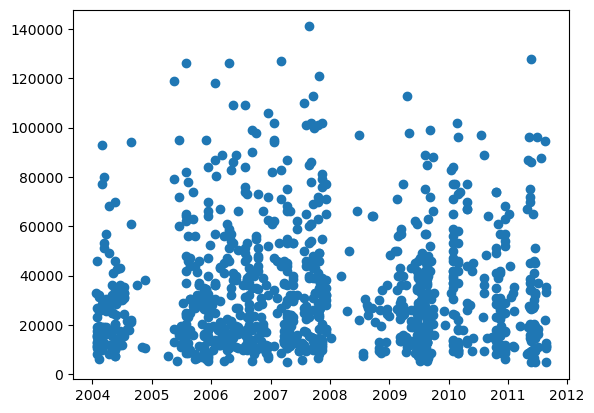

In [18]:
plt.scatter(df.saledate[:1000], df.SalePrice[:1000]);

In [20]:
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000.0,57000.0,10000.0,38500.0,11000.0
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


In [21]:
# Sort DataFrame by saledate
df.sort_values(by=["saledate"], inplace=True, ascending=True)
df.saledate.head(20)

205615   1989-01-17
274835   1989-01-31
141296   1989-01-31
212552   1989-01-31
62755    1989-01-31
54653    1989-01-31
81383    1989-01-31
204924   1989-01-31
135376   1989-01-31
113390   1989-01-31
113394   1989-01-31
116419   1989-01-31
32138    1989-01-31
127610   1989-01-31
76171    1989-01-31
127000   1989-01-31
128130   1989-01-31
127626   1989-01-31
55455    1989-01-31
55454    1989-01-31
Name: saledate, dtype: datetime64[ns]

In [22]:
# Make a copy of the data to keep the original intact  in case of manipulations
df_tmp = df.copy()

##### Add datetime parameters for `saledate` column

In [31]:
df_tmp["saleYear"] = df_tmp.saledate.dt.year
df_tmp["saleMonth"] = df_tmp.saledate.dt.month
df_tmp["saleDay"] = df_tmp.saledate.dt.day
df_tmp["saleDayOfWeek"] = df_tmp.saledate.dt.dayofweek
df_tmp["saleDayOfYear"] = df_tmp.saledate.dt.dayofyear

In [36]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1980,1978,1980,1984
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


In [37]:
# drop the saledate column
df_tmp.drop("saledate", axis = 1, inplace=True)

In [38]:
df_tmp.state.value_counts()

state
Florida           67320
Texas             53110
California        29761
Washington        16222
Georgia           14633
Maryland          13322
Mississippi       13240
Ohio              12369
Illinois          11540
Colorado          11529
New Jersey        11156
North Carolina    10636
Tennessee         10298
Alabama           10292
Pennsylvania      10234
South Carolina     9951
Arizona            9364
New York           8639
Connecticut        8276
Minnesota          7885
Missouri           7178
Nevada             6932
Louisiana          6627
Kentucky           5351
Maine              5096
Indiana            4124
Arkansas           3933
New Mexico         3631
Utah               3046
Unspecified        2801
Wisconsin          2745
New Hampshire      2738
Virginia           2353
Idaho              2025
Oregon             1911
Michigan           1831
Wyoming            1672
Montana            1336
Iowa               1336
Oklahoma           1326
Nebraska            866
West Virgi

### Handling missing values and data types

##### Converting strings to categories

In [40]:
# Find the columns which contain strings
for label, content in df_tmp.items():
    if pd.api.types.is_object_dtype(content):
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [41]:
# Convert them to category values
for label, content in df_tmp.items():
    if pd.api.types.is_object_dtype(content):
        df_tmp[label] = content.astype("category").cat.as_ordered()

In [42]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 412698 entries, 205615 to 409203
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   412698 non-null  int64   
 1   SalePrice                 412698 non-null  float64 
 2   MachineID                 412698 non-null  int64   
 3   ModelID                   412698 non-null  int64   
 4   datasource                412698 non-null  int64   
 5   auctioneerID              392562 non-null  float64 
 6   YearMade                  412698 non-null  int64   
 7   MachineHoursCurrentMeter  147504 non-null  float64 
 8   UsageBand                 73670 non-null   category
 9   fiModelDesc               412698 non-null  category
 10  fiBaseModel               412698 non-null  category
 11  fiSecondaryDesc           271971 non-null  category
 12  fiModelSeries             58667 non-null   category
 13  fiModelDescriptor         748

In [44]:
df_tmp.state.cat.codes

205615    43
274835     8
141296     8
212552     8
62755      8
          ..
410879     4
412476     4
411927     4
407124     4
409203     4
Length: 412698, dtype: int8

#### Fill missing values

In [46]:
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleYear
saleMonth
saleDay
saleDayOfWeek
saleDayOfYear


In [47]:
# Check  for the numeric columns that has null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

auctioneerID
MachineHoursCurrentMeter


In [48]:
# Fill the missing numeric rows with median
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Add a binary column which tells us if the data was missing
            df_tmp[label+"_is_missing"] = pd.isnull(content)
            # Fill missing numeric values with median
            df_tmp[label] = content.fillna(content.median())

In [49]:
df_tmp.isna().sum()

SalesID                                     0
SalePrice                                   0
MachineID                                   0
ModelID                                     0
datasource                                  0
auctioneerID                                0
YearMade                                    0
MachineHoursCurrentMeter                    0
UsageBand                              339028
fiModelDesc                                 0
fiBaseModel                                 0
fiSecondaryDesc                        140727
fiModelSeries                          354031
fiModelDescriptor                      337882
ProductSize                            216605
fiProductClassDesc                          0
state                                       0
ProductGroup                                0
ProductGroupDesc                            0
Drive_System                           305611
Enclosure                                 334
Forks                             

In [53]:
# Check to see how many examples were missing
df_tmp.auctioneerID_is_missing.value_counts()

auctioneerID_is_missing
False    392562
True      20136
Name: count, dtype: int64

##### Filling and turning categorical variables into numbers

In [54]:
# Check for columns which aren't numeric
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [55]:
# Turn categorical variables into numbers and fill missing
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        # Add binary column to indicate whether sample had missing value
        df_tmp[label+"_is_missing"] = pd.isnull(content)
        # Turn categories into numbers and add +1
        df_tmp[label] = pd.Categorical(content).codes+1

In [56]:
df_tmp.head().T

,205615,274835,141296,212552,62755
SalesID,1646770,1821514,1505138,1671174,1329056
SalePrice,9500.0,14000.0,50000.0,16000.0,22000.0
MachineID,1126363,1194089,1473654,1327630,1336053
ModelID,8434,10150,4139,8591,4089
datasource,132,132,132,132,132
...,...,...,...,...,...
Backhoe_Mounting_is_missing,False,True,False,True,False
Blade_Type_is_missing,False,True,False,True,False
Travel_Controls_is_missing,False,True,False,True,False
Differential_Type_is_missing,True,False,True,False,True


In [59]:
df_tmp.isna().sum()

SalesID                         0
SalePrice                       0
MachineID                       0
ModelID                         0
datasource                      0
                               ..
Backhoe_Mounting_is_missing     0
Blade_Type_is_missing           0
Travel_Controls_is_missing      0
Differential_Type_is_missing    0
Steering_Controls_is_missing    0
Length: 103, dtype: int64

## Modelling

#### Building a model using Random Forest

In [62]:
%%time 
# %%time checks for how long it will take our code to run

# Import the RandomForestRegression model
from sklearn.ensemble import RandomForestRegressor

# Instantiate the model
model = RandomForestRegressor(n_jobs=-1, random_state=42)

# Fit the model
model.fit(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

CPU times: total: 20min 16s
Wall time: 1min 39s


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
# Score the model on the training set
model.score(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

0.9875468079970562

##### Splitting data into train and validation sets
> All the data from 1989 to2011 is train sets and 2012 is validation sets

In [65]:
df_tmp.saleYear.value_counts()

saleYear
2009    43849
2008    39767
2011    35197
2010    33390
2007    32208
2006    21685
2005    20463
2004    19879
2001    17594
2000    17415
2002    17246
2003    15254
1998    13046
1999    12793
2012    11573
1997     9785
1996     8829
1995     8530
1994     7929
1993     6303
1992     5519
1991     5109
1989     4806
1990     4529
Name: count, dtype: int64

In [68]:
# Split data into training  and validation sets
df_val = df_tmp[df_tmp.saleYear == 2012]
df_train = df_tmp[df_tmp.saleYear != 2012]

In [70]:
len(df_val), len(df_train)

(11573, 401125)

In [71]:
# Split data into X and y
X_train, y_train = df_train.drop("SalePrice", axis =1), df_train.SalePrice
X_valid, y_valid = df_val.drop("SalePrice", axis=1), df_val.SalePrice

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((401125, 102), (401125,), (11573, 102), (11573,))

##### Building an evaluation function

In [13]:
# Create Root Mean Squared Log Error (RMSLE) evaluation function
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

def rmsle(y_test, y_preds):
    """
    Calculates root mean squared log error between predictions and true labels.
    """

    return np.sqrt(mean_squared_log_error(y_test, y_preds))

# Create function to evaluate model on a few different levels
def show_scores(model):
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_valid)
    scores = {"Training MAE": mean_absolute_error(y_train, train_preds),
              "Valid MAE": mean_absolute_error(y_valid, val_preds),
              "Training RMSLE": rmsle(y_train, train_preds),
              "Valid RMSLE": rmsle(y_valid, val_preds),
              "Training R^2": r2_score(y_train, train_preds),
              "Valid R^2": r2_score(y_valid, val_preds )}

    return scores

In [73]:
%%time

model = RandomForestRegressor(n_jobs=-1, random_state=42)

model.fit(X_train, y_train)

CPU times: total: 19min 18s
Wall time: 1min 32s


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
show_scores(model)

{'Training MAE': 1578.2015208725459,
 'Valid MAE': 6120.959637950402,
 'Training RMSLE': np.float64(0.08426351714047396),
 'Valid RMSLE': np.float64(0.25557446689440955),
 'Training R^2': 0.9875150955953674,
 'Valid R^2': 0.8727175969771312}

##### Testing the model on a subset to tune the hyperparameters

In [75]:
%%time

# Change max_samples value
model = RandomForestRegressor(n_jobs=-1, random_state=42, max_samples=10000)
model.fit(X_train, y_train)

CPU times: total: 40.1 s
Wall time: 3.46 s


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
show_scores(model)

{'Training MAE': 5561.298809224058,
 'Valid MAE': 7177.26365505919,
 'Training RMSLE': np.float64(0.25774537825697696),
 'Valid RMSLE': np.float64(0.29362638671089003),
 'Training R^2': 0.8606658995199188,
 'Valid R^2': 0.8320374995090507}

### Hyperparameter tuning with RandomizedSearchhCV

In [84]:
%%time

from sklearn.model_selection import RandomizedSearchCV

# Creating our parameter grid
grid = {'n_estimators':  [int(x) for x in np.linspace(start=100, stop=1000, num=10)],
        'max_features': ['sqrt', 'log2', None],
        'max_depth': [None, 3, 5, 10],
        'min_samples_split': [2, 5, 10, 15],
        'min_samples_leaf': np.arange(1, 20, 2)
       }

rs_model = RandomizedSearchCV(RandomForestRegressor(), param_distributions=grid, cv=5, verbose=2, random_state=42, n_jobs=-1, n_iter=10)
rs_model.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
CPU times: total: 14min 45s
Wall time: 1h 20min 25s


,estimator,RandomForestRegressor()
,param_distributions,"{'max_depth': [None, 3, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [85]:
rs_model.best_params_

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': np.int64(3),
 'max_features': None,
 'max_depth': None}

In [86]:
show_scores(rs_model)

{'Training MAE': 2697.7567828232695,
 'Valid MAE': 6044.818168500903,
 'Training RMSLE': np.float64(0.1369027253359384),
 'Valid RMSLE': np.float64(0.24943890066403704),
 'Training R^2': 0.9624141128042291,
 'Valid R^2': 0.8748611437959213}

In [87]:
# Most ideal hyperparameters
ideal_model = RandomForestRegressor(n_estimators=100,
                                    min_samples_leaf=1,
                                    min_samples_split=14,
                                    max_features=0.5,
                                    n_jobs=-1,
                                    max_samples=None,
                                    random_state=42)
ideal_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,14
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [88]:
show_scores(ideal_model)

{'Training MAE': 2926.928724023891,
 'Valid MAE': 5918.843241997182,
 'Training RMSLE': np.float64(0.14343207917693873),
 'Valid RMSLE': np.float64(0.24442584772365378),
 'Training R^2': 0.9597212791599464,
 'Valid R^2': 0.8833607837165849}

### Make predictions on test data

In [119]:
# Import the dataset
df_test = pd.read_csv("data/bluebook-for-bulldozers/Test.csv", low_memory=False, parse_dates=["saledate"])
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,2012-05-03,580G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,2012-05-10,936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,2012-05-10,EC210BLC,...,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,2012-05-10,330CL,...,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,2012-05-10,650K,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN


In [120]:
df_test.isna().sum()

SalesID                         0
MachineID                       0
ModelID                         0
datasource                      0
auctioneerID                    0
YearMade                        0
MachineHoursCurrentMeter    10328
UsageBand                   10623
saledate                        0
fiModelDesc                     0
fiBaseModel                     0
fiSecondaryDesc              3975
fiModelSeries               10451
fiModelDescriptor            9433
ProductSize                  6409
fiProductClassDesc              0
state                           0
ProductGroup                    0
ProductGroupDesc                0
Drive_System                 9698
Enclosure                       2
Forks                        6149
Pad_Type                    10349
Ride_Control                 8216
Stick                       10349
Transmission                 7639
Turbocharged                10349
Blade_Extension             11806
Blade_Width                 11806
Enclosure_Type

In [121]:
# Preprocessing the data to be in the same format as our training dataset
def preprocess_data(df):
    """
    Performs trannsformations on df and returns transformed df
    """
    df["saleYear"] = df.saledate.dt.year
    df["saleMonth"] = df.saledate.dt.month
    df["saleDay"] = df.saledate.dt.day
    df["saleDayOfWeek"] = df.saledate.dt.dayofweek
    df["saleDayOfYear"] = df.saledate.dt.dayofyear
    df.drop("saledate", axis = 1, inplace=True)

    # Convert string columns them to category values
    for label, content in df.items():
        if pd.api.types.is_object_dtype(content):
            df[label] = content.astype("category").cat.as_ordered()

    # Fill the missing numeric rows with median
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                # Add a binary column which tells us if the data was missing
                df[label+"_is_missing"] = pd.isnull(content)
                # Fill missing numeric values with median
                df[label] = content.fillna(content.median())

    # Turn categorical variables into numbers and fill missing
    for label, content in df.items():
        if not pd.api.types.is_numeric_dtype(content):
            # Add binary column to indicate whether sample had missing value
            df[label+"_is_missing"] = pd.isnull(content)
            # Turn categories into numbers and add +1
            df[label] = pd.Categorical(content).codes+1

    return df

In [122]:
preprocess_data(df_test)
df_test.head().T

,0,1,2,3,4
SalesID,1227829,1227844,1227847,1227848,1227863
MachineID,1006309,1022817,1031560,56204,1053887
ModelID,3168,7271,22805,1269,22312
datasource,121,121,121,121,121
auctioneerID,3,3,3,3,3
...,...,...,...,...,...
Backhoe_Mounting_is_missing,True,True,True,True,False
Blade_Type_is_missing,True,True,True,True,False
Travel_Controls_is_missing,True,True,True,True,False
Differential_Type_is_missing,True,False,True,True,True


In [123]:
# Since some auctioneerID_is_missing has no missing values in the test set, we will create a column that takes False as the values
# To maintain the order of features, it will be inserted at the 57 loc like the training set
df_test.insert(56, 'auctioneerID_is_missing', False)
df_test.columns

Index(['SalesID', 'MachineID', 'ModelID', 'datasource', 'auctioneerID',
       'YearMade', 'MachineHoursCurrentMeter', 'UsageBand', 'fiModelDesc',
       'fiBaseModel',
       ...
       'Undercarriage_Pad_Width_is_missing', 'Stick_Length_is_missing',
       'Thumb_is_missing', 'Pattern_Changer_is_missing',
       'Grouser_Type_is_missing', 'Backhoe_Mounting_is_missing',
       'Blade_Type_is_missing', 'Travel_Controls_is_missing',
       'Differential_Type_is_missing', 'Steering_Controls_is_missing'],
      dtype='object', length=102)

In [124]:
# Make predictions on the test dataset
test_preds = ideal_model.predict(df_test)

In [125]:
test_preds

array([17235.85943419, 15513.96916168, 48289.36657317, ...,
       13691.57177177, 17199.78962647, 27177.5361297 ], shape=(12457,))

In [128]:
# Creating a dataframe that has rge salesid and the predicted sales price
df_preds = pd.DataFrame()
df_preds["SalesID"] = df_test["SalesID"]
df_preds["SalePrice"] = test_preds
df_preds

,SalesID,SalePrice
0,1227829,17235.859434
1,1227844,15513.969162
2,1227847,48289.366573
3,1227848,66968.602614
4,1227863,60501.485122
...,...,...
12452,6643171,37479.180237
12453,6643173,13097.742026
12454,6643184,13691.571772
12455,6643186,17199.789626


In [130]:
# Export prediction data
df_preds.to_csv("data/bluebook-for-bulldozers/test_predictions_1.csv", index=False)

### Feature Importance

In [132]:
rf_importance = pd.Series(ideal_model.feature_importances_, index=df_test.columns).sort_values(ascending=False)
rf_importance

YearMade                         0.203703
ProductSize                      0.148142
saleYear                         0.073594
Enclosure                        0.066974
fiSecondaryDesc                  0.062249
                                   ...   
fiProductClassDesc_is_missing    0.000000
state_is_missing                 0.000000
ProductGroup_is_missing          0.000000
ProductGroupDesc_is_missing      0.000000
fiModelDesc_is_missing           0.000000
Length: 102, dtype: float64

In [139]:
# Filter out features with an importance score of 0.001
rf_importance = rf_importance[rf_importance > 0.001]
rf_importance

YearMade                               0.203703
ProductSize                            0.148142
saleYear                               0.073594
Enclosure                              0.066974
fiSecondaryDesc                        0.062249
fiProductClassDesc                     0.045870
fiModelDesc                            0.045401
fiBaseModel                            0.042159
ModelID                                0.041494
SalesID                                0.033486
ProductSize_is_missing                 0.030340
MachineID                              0.020881
fiModelDescriptor                      0.019673
Coupler_System_is_missing              0.013486
Coupler_System                         0.013443
saleDayOfYear                          0.009830
Blade_Width                            0.008768
Tire_Size                              0.007348
state                                  0.005957
saleDay                                0.005700
Tire_Size_is_missing                   0

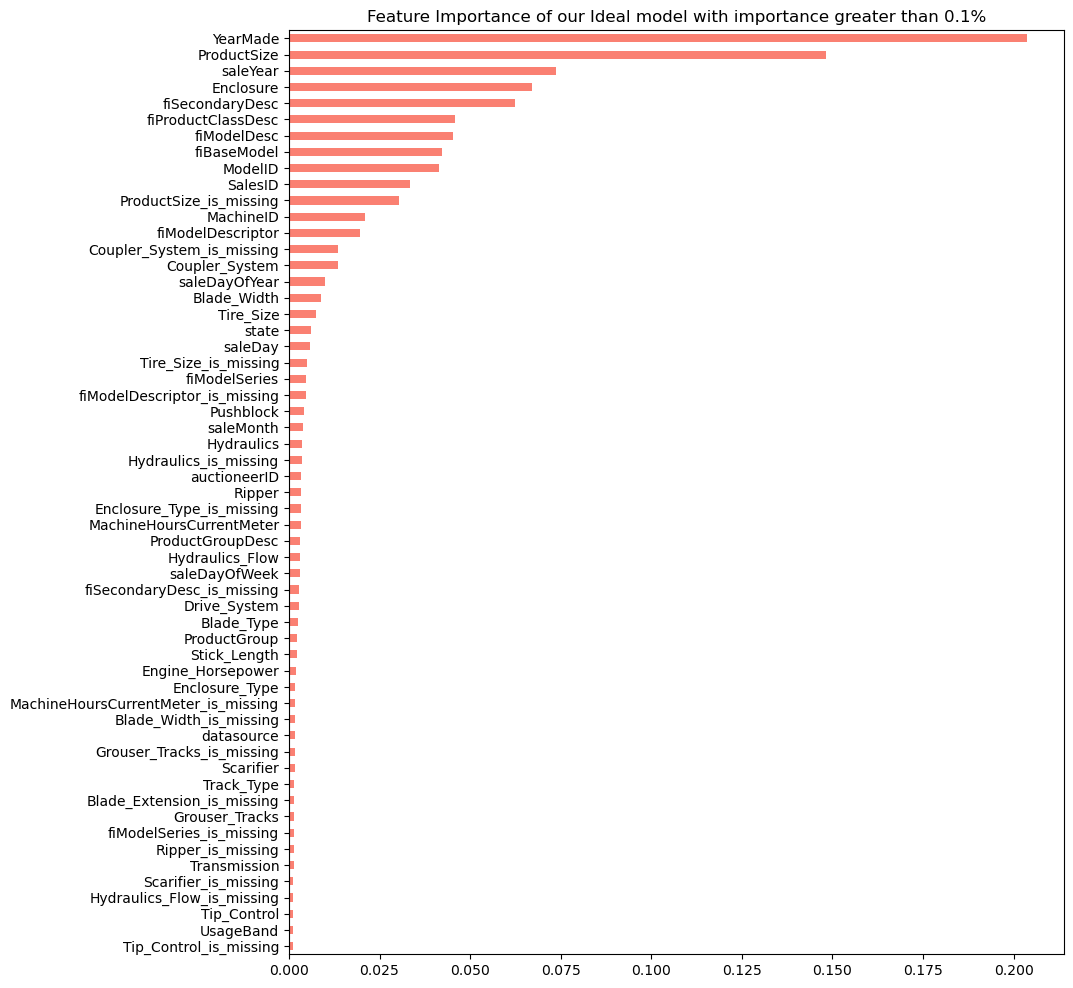

In [143]:
# Visualizing the feature importances
rf_importance.plot.barh(legend=False, color='salmon',  figsize=(10, 12))
plt.gca().invert_yaxis()
plt.title("Feature Importance of our Ideal model with importance greater than 0.1%");

### Finding the best hyperparameters using GridSearchCV

In [2]:
# Import the training data
train_set = pd.read_csv("data/bluebook-for-bulldozers/Train.csv", low_memory=False, parse_dates=["saledate"])

# Splitting the data into features and label
train_features = train_set.drop("SalePrice", axis=1)
train_labels = train_set["SalePrice"]

train_features.shape, train_labels.shape

((401125, 52), (401125,))

In [3]:
# Preprocessing our train_features using a preprocessing data function
def data_preprocess(df):
    """
    Performs trannsformations on df and returns transformed df
    """
    df["saleYear"] = df.saledate.dt.year
    df["saleMonth"] = df.saledate.dt.month
    df["saleDay"] = df.saledate.dt.day
    df["saleDayOfWeek"] = df.saledate.dt.dayofweek
    df["saleDayOfYear"] = df.saledate.dt.dayofyear
    df.drop("saledate", axis = 1, inplace=True)

    # Convert string columns them to category values
    for label, content in df.items():
        if pd.api.types.is_object_dtype(content):
            df[label] = content.astype("category").cat.as_ordered()

    # Fill the missing numeric rows with median
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                # Fill missing numeric values with median
                df[label] = content.fillna(content.median())

    # Turn categorical variables into numbers and fill missing
    for label, content in df.items():
        if not pd.api.types.is_numeric_dtype(content):
            # Turn categories into numbers and add +1
            df[label] = pd.Categorical(content).codes+1

    return df

In [4]:
data_preprocess(train_features)

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayOfWeek,saleDayOfYear
0,1139246,999089,3157,121,3.0,2004,68.0,2,950,296,...,0,0,0,4,2,2006,11,16,3,320
1,1139248,117657,77,121,3.0,1996,4640.0,2,1725,527,...,0,0,0,4,2,2004,3,26,4,86
2,1139249,434808,7009,121,3.0,2001,2838.0,1,331,110,...,0,0,0,0,0,2004,2,26,3,57
3,1139251,1026470,332,121,3.0,2001,3486.0,1,3674,1375,...,0,0,0,0,0,2011,5,19,3,139
4,1139253,1057373,17311,121,3.0,2007,722.0,3,4208,1529,...,0,0,0,0,0,2009,7,23,3,204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401120,6333336,1840702,21439,149,1.0,2005,0.0,0,657,207,...,0,0,0,0,0,2011,11,2,2,306
401121,6333337,1830472,21439,149,1.0,2005,0.0,0,657,207,...,0,0,0,0,0,2011,11,2,2,306
401122,6333338,1887659,21439,149,1.0,2005,0.0,0,657,207,...,0,0,0,0,0,2011,11,2,2,306
401123,6333341,1903570,21435,149,2.0,2005,0.0,0,483,159,...,0,0,0,0,0,2011,10,25,1,298


In [26]:
%%time

# Import the GridSearchCV library
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_log_error, make_scorer
from sklearn.ensemble import RandomForestRegressor

# Set the parameter grid
gs_grid = {"n_estimators": [100, 120],
           "max_features": [0.5],
           "min_samples_split": [12, 14, 16],
           "min_samples_leaf": [1, 2, 3],
           "max_samples": [None]
}

# Setup GriidSearchCv with rmsle scorer
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                     param_grid=gs_grid,
                     cv=5,
                     n_jobs=-1,
                     verbose=2)

gs_rf.fit(train_features, train_labels)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
CPU times: total: 4min 54s
Wall time: 43min 52s


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_features': [0.5], 'max_samples': [None], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [12, 14, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [27]:
gs_rf.best_params_

{'max_features': 0.5,
 'max_samples': None,
 'min_samples_leaf': 3,
 'min_samples_split': 14,
 'n_estimators': 100}

In [47]:
# Most ideal hyperparameters
ideal_model = RandomForestRegressor(n_estimators=100,
                                    min_samples_leaf=1,
                                    min_samples_split=14,
                                    max_features=0.5,
                                    n_jobs=-1,
                                    max_samples=None,
                                    random_state=42)
ideal_model.fit(X_train, y_train)

NameError: name 'ideal_model' is not defined

In [28]:
gs_rf.score(train_features, train_labels)

0.9524139161827361

In [37]:
df = pd.read_csv("data/bluebook-for-bulldozers/TrainAndValid.csv", low_memory=False, parse_dates=["saledate"])
df

df["saleYear"] = df.saledate.dt.year
df["saleMonth"] = df.saledate.dt.month
df["saleDay"] = df.saledate.dt.day
df["saleDayOfWeek"] = df.saledate.dt.dayofweek
df["saleDayOfYear"] = df.saledate.dt.dayofyear
df.drop("saledate", axis = 1, inplace=True)

# Split data into training  and validation sets
df_val = df[df.saleYear == 2012]
df_train = df[df.saleYear != 2012]

# Split data into X and y
X_train, y_train = df_train.drop("SalePrice", axis =1), df_train.SalePrice
X_valid, y_valid = df_val.drop("SalePrice", axis=1), df_val.SalePrice

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((401125, 56), (401125,), (11573, 56), (11573,))

In [41]:
# Preprocessing our train_features using a preprocessing data function
def data_preprocess(df):
    """
    Performs trannsformations on df and returns transformed df
    """

    # Convert string columns them to category values
    for label, content in df.items():
        if pd.api.types.is_object_dtype(content):
            df[label] = content.astype("category").cat.as_ordered()

    # Fill the missing numeric rows with median
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                # Fill missing numeric values with median
                df[label] = content.fillna(content.median())

    # Turn categorical variables into numbers and fill missing
    for label, content in df.items():
        if not pd.api.types.is_numeric_dtype(content):
            # Turn categories into numbers and add +1
            df[label] = pd.Categorical(content).codes+1

    return df

In [42]:
data_preprocess(X_valid)

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayOfWeek,saleDayOfYear
401125,1222837,902859,1376,121,3.0,1000,0.0,0,294,122,...,0,0,0,0,0,2012,1,5,3,5
401126,1222839,1048320,36526,121,3.0,2006,4412.0,3,1612,728,...,0,0,0,0,0,2012,1,5,3,5
401127,1222841,999308,4587,121,3.0,2000,10127.0,3,161,75,...,0,0,0,0,0,2012,1,5,3,5
401128,1222843,1062425,1954,121,3.0,1000,4682.0,2,687,248,...,0,0,0,0,0,2012,1,5,3,5
401129,1222845,1032841,4701,121,3.0,2002,8150.0,3,398,156,...,0,0,0,3,2,2012,1,4,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412693,6333344,1919201,21435,149,2.0,2005,3786.0,0,196,83,...,0,0,0,0,0,2012,3,7,2,67
412694,6333345,1882122,21436,149,2.0,2005,3786.0,0,197,83,...,0,0,0,0,0,2012,1,28,5,28
412695,6333347,1944213,21435,149,2.0,2005,3786.0,0,196,83,...,0,0,0,0,0,2012,1,28,5,28
412696,6333348,1794518,21435,149,2.0,2006,3786.0,0,196,83,...,0,0,0,0,0,2012,3,7,2,67


In [43]:
X_valid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11573 entries, 401125 to 412697
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SalesID                   11573 non-null  int64  
 1   MachineID                 11573 non-null  int64  
 2   ModelID                   11573 non-null  int64  
 3   datasource                11573 non-null  int64  
 4   auctioneerID              11573 non-null  float64
 5   YearMade                  11573 non-null  int64  
 6   MachineHoursCurrentMeter  11573 non-null  float64
 7   UsageBand                 11573 non-null  int8   
 8   fiModelDesc               11573 non-null  int16  
 9   fiBaseModel               11573 non-null  int16  
 10  fiSecondaryDesc           11573 non-null  int8   
 11  fiModelSeries             11573 non-null  int8   
 12  fiModelDescriptor         11573 non-null  int8   
 13  ProductSize               11573 non-null  int8   
 14  fiPro

In [44]:
# Create Root Mean Squared Log Error (RMSLE) evaluation function
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score

def rmsle(y_test, y_preds):
    """
    Calculates root mean squared log error between predictions and true labels.
    """

    return np.sqrt(mean_squared_log_error(y_test, y_preds))

# Create function to evaluate model on a few different levels
def show_scores_1(model):
    train_preds = model.predict(train_features)
    val_preds = model.predict(X_valid)
    scores = {"Training MAE": mean_absolute_error(train_labels, train_preds),
              "Valid MAE": mean_absolute_error(y_valid, val_preds),
              "Training RMSLE": rmsle(train_labels, train_preds),
              "Valid RMSLE": rmsle(y_valid, val_preds),
              "Training R^2": r2_score(train_labels, train_preds),
              "Valid R^2": r2_score(y_valid, val_preds )}

    return scores

In [45]:
show_scores_1(gs_rf)

{'Training MAE': 3125.100668508304,
 'Valid MAE': 10343.704990334463,
 'Training RMSLE': np.float64(0.15397327106267103),
 'Valid RMSLE': np.float64(0.40126989487509024),
 'Training R^2': 0.9524139161827361,
 'Valid R^2': 0.6287640160642642}

In [48]:
gs_rf

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_features': [0.5], 'max_samples': [None], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [12, 14, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [49]:
# Exporting the gs_rf model
from joblib import dump, load
dump(gs_rf, 'GridSearchCV_random_forest_model_1.joblib')

['GridSearchCV_random_forest_model_1.joblib']

In [50]:
# exporting the ideal_model
ideal_model = RandomForestRegressor(n_estimators=100,
                                    min_samples_leaf=1,
                                    min_samples_split=14,
                                    max_features=0.5,
                                    n_jobs=-1,
                                    max_samples=None,
                                    random_state=42)
ideal_model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Low'